# Notebook 1: ETL & Preprocessing Pipeline
**Coursework: Market Basket Analysis on Online Retail Dataset**

This notebook is responsible for data ingestion, exploratory data analysis (EDA), anomaly detection, and transforming the transactional data into the specific Boolean matrix format required for Association Rule Mining.


## 1. Data Loading & Initial Inspection
We begin by importing the required libraries and loading our raw data. The 'Online Retail' dataset frequently contains European text characters, so we utilize `latin1` encoding to prevent parsing errors.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
data_path = 'Market_Basket_Analysis/raw_data/online_retail.xlsx'

# Load the dataset
print("Loading dataset...")
try:
    pd.read_excel(data_path, engine='openpyxl')
    df_raw = pd.read_excel(data_path, engine='openpyxl') #pd.read_csv(data_path, encoding='latin1')
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: {data_path} not found. Please ensure the file is in the correct directory.")
    # Fallback mock for pure execution context if needed
    df_raw = pd.DataFrame()

# Display basic information
if not df_raw.empty:
    print("\n--- Dataset Info ---")
    df_raw.info()

    print("\n--- First 5 Rows ---")
    display(df_raw.head())


Loading dataset...
Data loaded successfully.

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB

--- First 5 Rows ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Descriptive Statistics
Understanding the distributions and general central tendencies of the numerical features and the cardinality of categorical variables.


In [14]:
if not df_raw.empty:
    print("\n--- Numerical Summaries ---")
    display(df_raw.describe())

    print("\n--- Categorical Summaries ---")
    display(df_raw.describe(include=['O', 'string']))



--- Numerical Summaries ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



--- Categorical Summaries ---


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


## 3. Exploratory Data Analysis (EDA)
Let's visualize the data to extract macroscopic trends before diving into microscopic item associations.


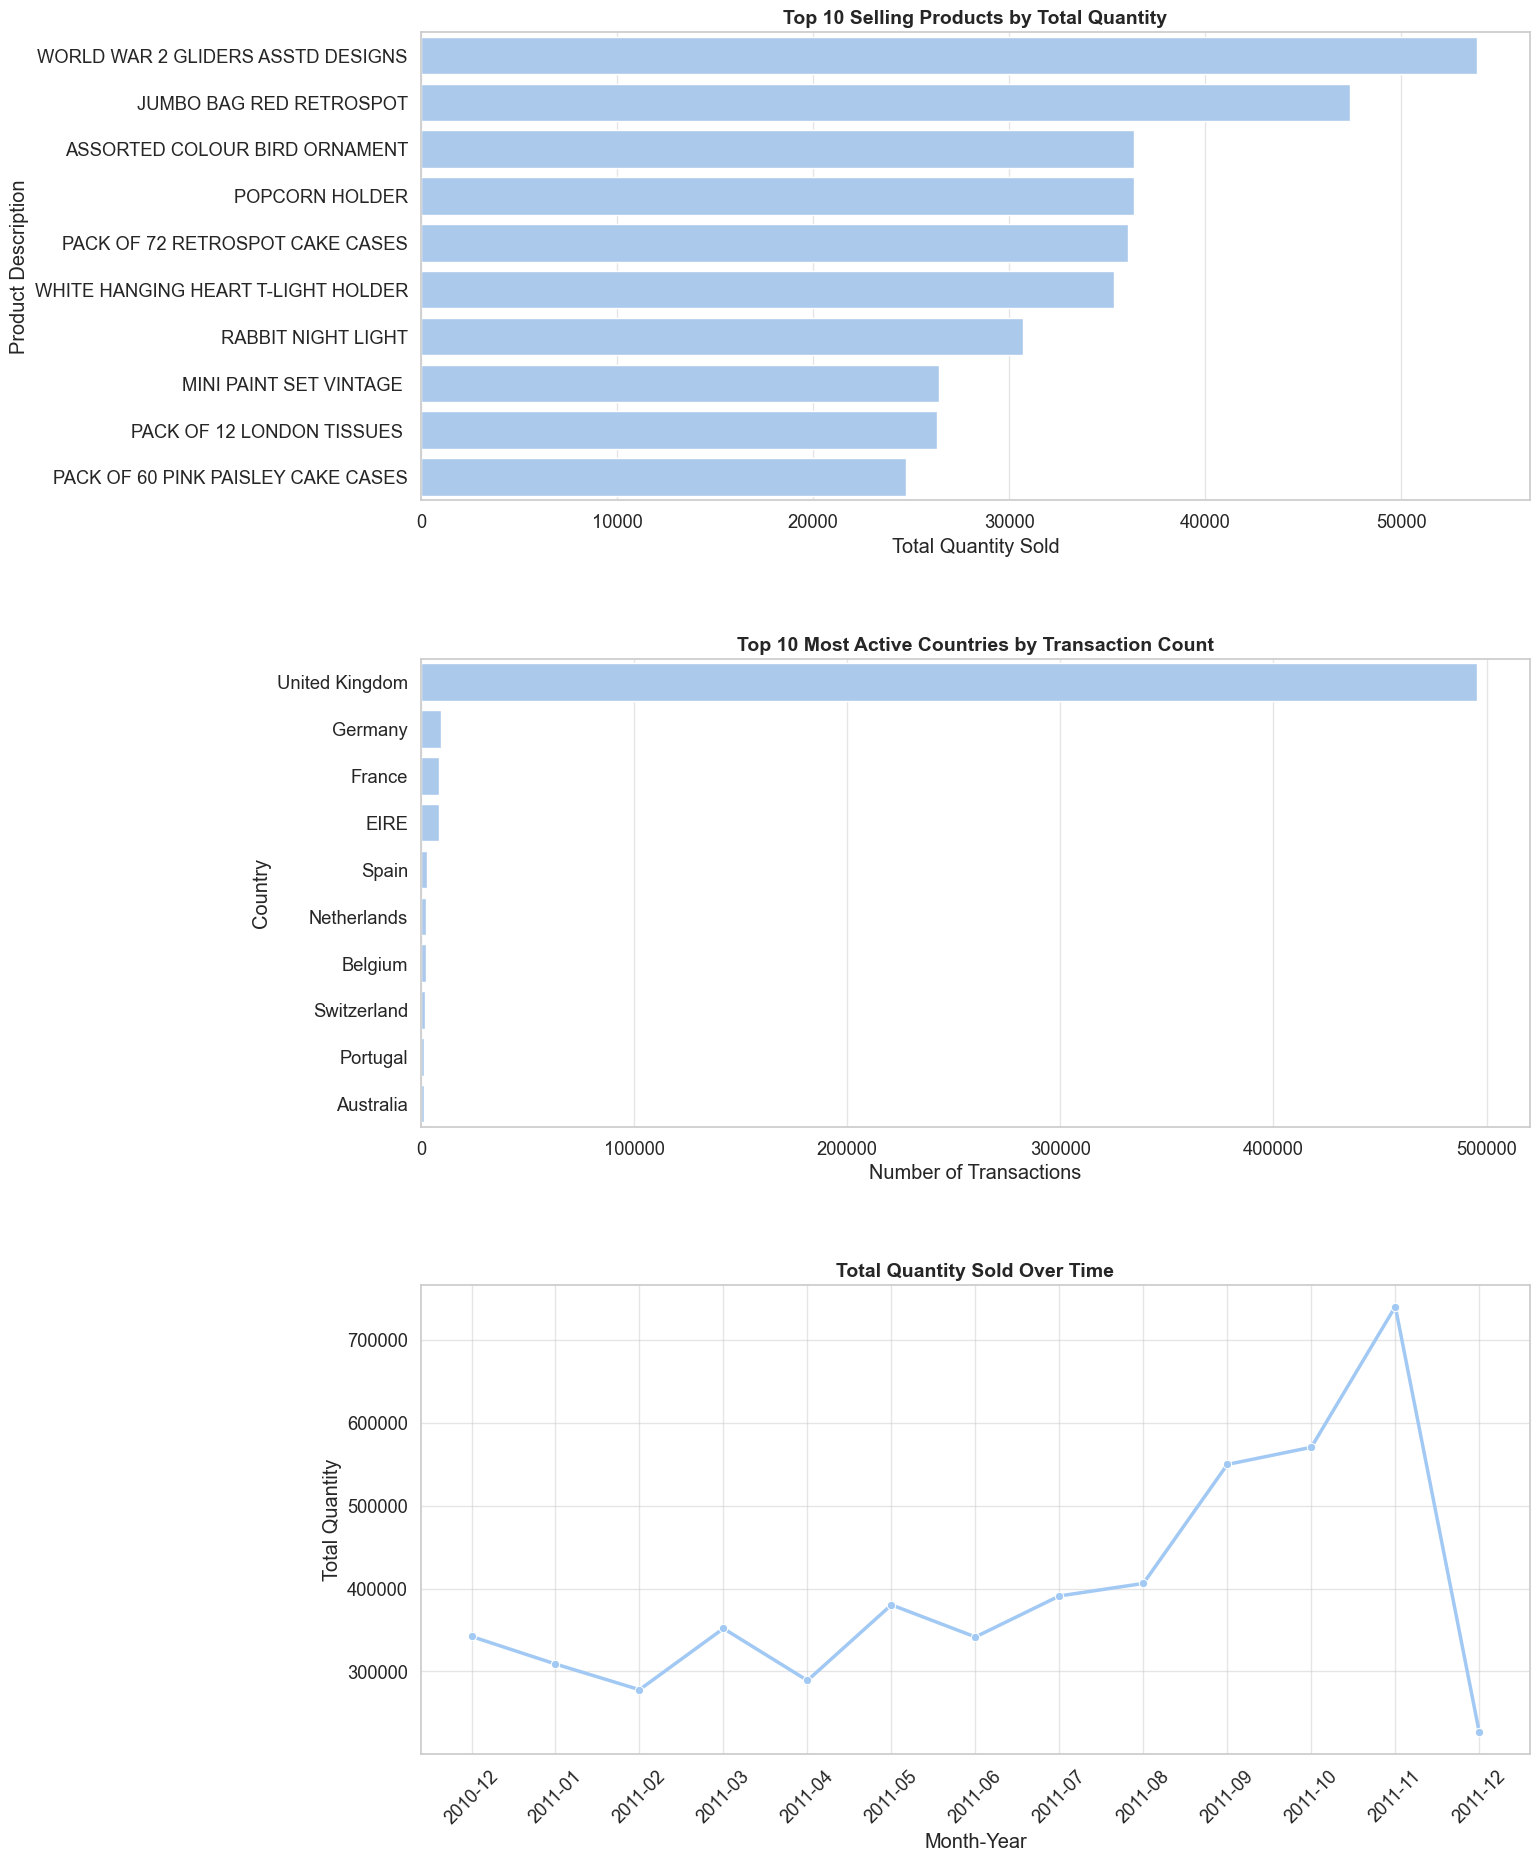

In [30]:
# Set modern aesthetic for seaborn
sns.set_theme(style="whitegrid", palette="pastel", font="Arial", font_scale=1.2, rc={'figure.figsize': (12, 8)}, context="notebook", axis_labels_fontsize=14, axis_title_fontsize=14, label_fontsize=14, legend_fontsize=12, title_fontsize=16, title_fontweight='bold')

if not df_raw.empty:
    # Convert InvoiceDate to datetime
    df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

    # Extract Month-Year for trend analysis
    df_raw['YearMonth'] = df_raw['InvoiceDate'].dt.to_period('M')

    fig, axes = plt.subplots(3, 1, figsize=(14, 20))
    fig.tight_layout(pad=6.0)

    # Plot 1: Top 10 Selling Products (by Quantity)
    top_products = df_raw.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0])
    axes[0].set_title('Top 10 Selling Products by Total Quantity', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Total Quantity Sold')
    axes[0].set_ylabel('Product Description')

    # Plot 2: Top 10 Active Countries (by Transaction Count)
    top_countries = df_raw['Country'].value_counts().head(10)
    sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1])
    axes[1].set_title('Top 10 Most Active Countries by Transaction Count', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Transactions')
    axes[1].set_ylabel('Country')

    # Plot 3: Sales Trend Over Time
    monthly_sales = df_raw.groupby('YearMonth')['Quantity'].sum()
    monthly_sales.index = monthly_sales.index.astype(str)
    sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[2], marker='o', linewidth=2.5)
    axes[2].set_title('Total Quantity Sold Over Time', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Month-Year')
    axes[2].set_ylabel('Total Quantity')
    axes[2].tick_params(axis='x', rotation=45)

    plt.show()


## 4. Anomaly & Outlier Detection
**Academic Justification:**
1. **Missing Descriptions:** Without a description, we cannot identify the item in a basket. We must drop these.
2. **Missing CustomerID:** While tracking customers is useful for demographics, Market Basket Analysis relies primarily on `InvoiceNo` to define a "basket". We will retain records with missing CustomerIDs as long as the InvoiceNo and Description are valid, preserving valuable transaction data.
3. **Cancellations:** Invoices starting with 'C' are returns/cancellations. Including them would negate actual purchases and skew our support counts. They must be removed.
4. **Negative/Zero Values:** Zero or negative prices/quantities represent damaged goods or accounting adjustments. We filter for `Quantity > 0` and `UnitPrice > 0`.
5. **Whitespace:** We strip whitespace from descriptions to prevent duplicating items (e.g., "MUG" vs "MUG ").


In [16]:
if not df_raw.empty:
    df_clean = df_raw.copy()

    # Strip trailing/leading spaces from description
    df_clean['Description'] = df_clean['Description'].str.strip()

    # Drop missing descriptions
    df_clean.dropna(subset=['Description'], inplace=True)

    # Remove cancellations (InvoiceNo containing 'C')
    df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.contains('C', na=False)]

    # Filter strictly positive quantities and prices
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

    print(f"Data remaining after cleaning: {len(df_clean)} rows (started with {len(df_raw)} rows).")



Data remaining after cleaning: 530104 rows (started with 541909 rows).


## 5. Market Basket Data Preparation
We must transition the data from a long format (one row per item) to a wide, one-hot encoded matrix format (one row per basket/invoice, one column per item).

We will create global data, but also isolate the Top 3 countries for localized analysis: **United Kingdom, Germany, and France**.


In [17]:
def create_basket(df):
    """
    Groups the dataframe by InvoiceNo and Description, summing Quantities.
    Then unstacking transforms items into columns.
    Finally, we cast quantities to standard booleans (True/False) as required by mlxtend.
    """
    basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
              .sum().unstack().reset_index().fillna(0)
              .set_index('InvoiceNo'))

    # Convert quantities to booleans (1/0 or True/False)
    basket_bool = basket > 0
    return basket_bool


if not df_raw.empty:
    print("Generating boolean baskets...")
    # 1. Global Basket
    basket_global = create_basket(df_clean)
    print(f"Global Basket Shape: {basket_global.shape}")

    # 2. Top 3 Countries
    basket_uk = create_basket(df_clean[df_clean['Country'] == 'United Kingdom'])
    basket_germany = create_basket(df_clean[df_clean['Country'] == 'Germany'])
    basket_france = create_basket(df_clean[df_clean['Country'] == 'France'])

    print(f"UK Basket Shape: {basket_uk.shape}")
    print(f"Germany Basket Shape: {basket_germany.shape}")
    print(f"France Basket Shape: {basket_france.shape}")


Generating boolean baskets...
Global Basket Shape: (19960, 4015)
UK Basket Shape: (18019, 3996)
Germany Basket Shape: (457, 1694)
France Basket Shape: (392, 1563)


## 6. Data Export
We will save these cleaned, preprocessed Boolean matrices to CSV files. The mining notebook will load these files to separate the intensive data manipulation from the algorithmic modeling.


In [19]:
import os

output_dir = "Market_Basket_Analysis/processed_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

if not df_raw.empty:
    print("Exporting data to CSV...")

    # Since boolean matrices can be large, we save as integers (0/1) to save disk space
    basket_global.astype(int).to_csv(f"{output_dir}/online_retail_processed_global.csv")
    basket_uk.astype(int).to_csv(f"{output_dir}/online_retail_processed_uk.csv")
    basket_germany.astype(int).to_csv(f"{output_dir}/online_retail_processed_germany.csv")
    basket_france.astype(int).to_csv(f"{output_dir}/online_retail_processed_france.csv")

    print("Export complete. Ready for Association Rule Mining.")

Exporting data to CSV...
Export complete. Ready for Association Rule Mining.
